Défi quotidien : analyse stratégique de la performance des supermarchés

👩 🏫 👩🏿 🏫 Ce que tu apprendras
Comment traduire les objectifs métier en questions d’analyse de données exploitables.
Comment utiliser Matplotlib et Seaborn pour des visualisations diagnostiques et communicatives.
Comment créer des widgets interactifs pour l’exploration dynamique des données.
Comment obtenir et présenter des informations exploitables à partir des données de vente au détail.
Comment structurer un carnet d’analyse professionnel et un résumé exécutif.

🛠️ Ce que tu vas créer
Vous construirez un rapport complet d’intelligence économique dans un Jupyter Notebook en utilisant le jeu de données US Superstore. Cela inclura des visualisations interactives, des diagnostics approfondis et des recommandations stratégiques qui simulent le rôle d’analyste de données pour un détaillant national.

Que vas-tu utiliser
Concepts : analyse diagnostique, visualisations exploratoires vs. explicatives, marge bénéficiaire, indicateurs stratégiques de performance
Bibliothèques : Pandas, Matplotlib, Seaborn, ipywidgets
Techniques : analyse de séries temporelles, analyse géographique, diagnostic de stratégies de réduction, tableaux de bord interactifs

Votre tâche
1. Définition et préparation des données

Téléchargez et chargez le jeu de données US Superstore. Commencez par une évaluation préliminaire des données :

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('superstore_dataset.csv')

# Basic data exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.info()
df.describe()
df.isnull().sum()

Dataset Shape: (10, 9)

Column Names:
['Order Date', 'Ship Date', 'Category', 'Product Name', 'Sales', 'Profit', 'Discount', 'State', 'Postal Code']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    10 non-null     datetime64[ns]
 1   Ship Date     10 non-null     datetime64[ns]
 2   Category      10 non-null     object        
 3   Product Name  10 non-null     object        
 4   Sales         10 non-null     int64         
 5   Profit        10 non-null     int64         
 6   Discount      10 non-null     float64       
 7   State         10 non-null     object        
 8   Postal Code   10 non-null     int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(3)
memory usage: 852.0+ bytes


,0
Order Date,0
Ship Date,0
Category,0
Product Name,0
Sales,0
Profit,0
Discount,0
State,0
Postal Code,0


Clean and preprocess your data:

🧹 Handle missing values and duplicates
Use appropriate methods (, , or imputation) and justify your choices for each case in markdown cells.dropna()fillna()

In [85]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Handle missing values (example approach)
print("\nMissing values per column:")
print(df.isnull().sum())

# Example: Fill missing postal codes with 0 or remove rows
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)

Duplicate rows: 0

Missing values per column:
Order Date      0
Ship Date       0
Category        0
Product Name    0
Sales           0
Profit          0
Discount        0
State           0
Postal Code     0
dtype: int64


🕓 Fix data types
Ensure that date columns are converted to objects using for time-series analysis.datetimepd.to_datetime()

In [86]:
# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# Verify the conversion
print("Data types after conversion:")
print(df[date_columns].dtypes)

Data types after conversion:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


🏗️ Feature engineering
Create new features to enrich your analysis:
Profit Margin = (Profit / Sales) * 100
Order Year (e.g., df['Order Date'].dt.year)
Order Month (e.g., df['Order Date'].dt.month)

In [87]:
# Feature engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# Display sample of new features
print("New features created:")
print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month']].head())

New features created:
   Sales  Profit  Profit Margin  Order Year  Order Month
0   1000     100      10.000000        2020            1
1    500      50      10.000000        2020            1
2     50      10      20.000000        2020            2
3    800     -50      -6.250000        2020            3
4   1200     200      16.666667        2020            1


2. Deep-Dive Exploratory Analysis (Matplotlib)

📈 Time-Series Trend Analysis
Create a line plot of total monthly Sales across all years using Matplotlib.
Add interactivity with to select a Product Category, dynamically updating the chart. ipywidgets.Dropdown

🔎 Look for patterns: seasonality, year-over-year changes, product-specific trends.

In [88]:
# Prepare data for time series analysis
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

In [69]:
# Interactive time series plot
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # Plot total sales across all categories
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        # Plot sales for specific category
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'],
                marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [104]:
# Create interactive widget
categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Technology', 'Office Sup…

<Figure size 1200x600 with 0 Axes>

🗺️ Geographic Sales Performance
Build a horizontal bar chart showing total sales by State, sorted by amount.
Add a slider widget to dynamically filter the number of displayed states. Top N

💬 Identify high-performing states. Are sales centralized or geographically distributed?

In [90]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

In [107]:
# Interactive geographic analysis
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    # Get top N states
    top_states = state_sales.tail(top_n)

    # Create horizontal bar chart
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    # Add value labels on bars
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values()) * 0.01, i, f'${value:,.0f}',
                va='center', fontsize=10)

    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Total states analyzed: {len(state_sales)}")
    print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales")

In [106]:
# Create interactive slider
top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

interactive(children=(IntSlider(value=10, description='n', max=30, min=-10), Output()), _dom_classes=('widget-…

3. Communicating Insights (Seaborn)

🏆 Top 10 Most Profitable Products
Use Seaborn’s to show the top 10 products by total profit.
- Orient horizontally, label axes clearly, and annotate bars with exact profit values.
- Give the chart a descriptive title suitable for an executive summary.barplot()

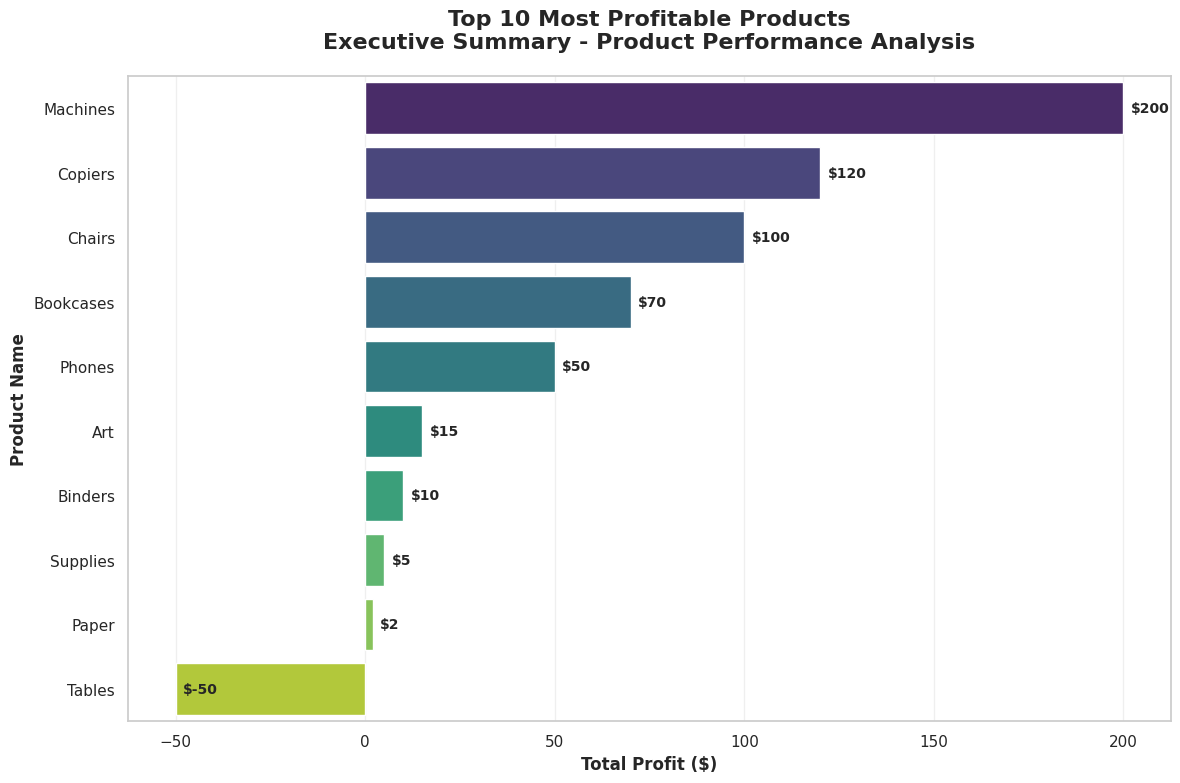

In [109]:
# Analyze top profitable products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                palette='viridis', orient='h')

# Customize the plot
plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

# Add value annotations
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + max(product_profit.values()) * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [93]:
print("Key Insights:")
print(f"• Most profitable product generates: ${product_profit.iloc[0]:,.0f}")
print(f"• Top 10 products contribute: ${product_profit.sum():,.0f} total profit")
print(f"• Average profit per top product: ${product_profit.mean():,.0f}")

Key Insights:
• Most profitable product generates: $200
• Top 10 products contribute: $522 total profit
• Average profit per top product: $52


🔍 Discount vs Profit Scatter Plot
Use to visualize the relationship between Discount and Profit.
- Add to reveal category-level trends.
- Overlay a to visualize trend lines. sns.scatterplot()hue=Product Categoryregplot()

❗ What discount level starts correlating with consistent losses? Varying trends by category?

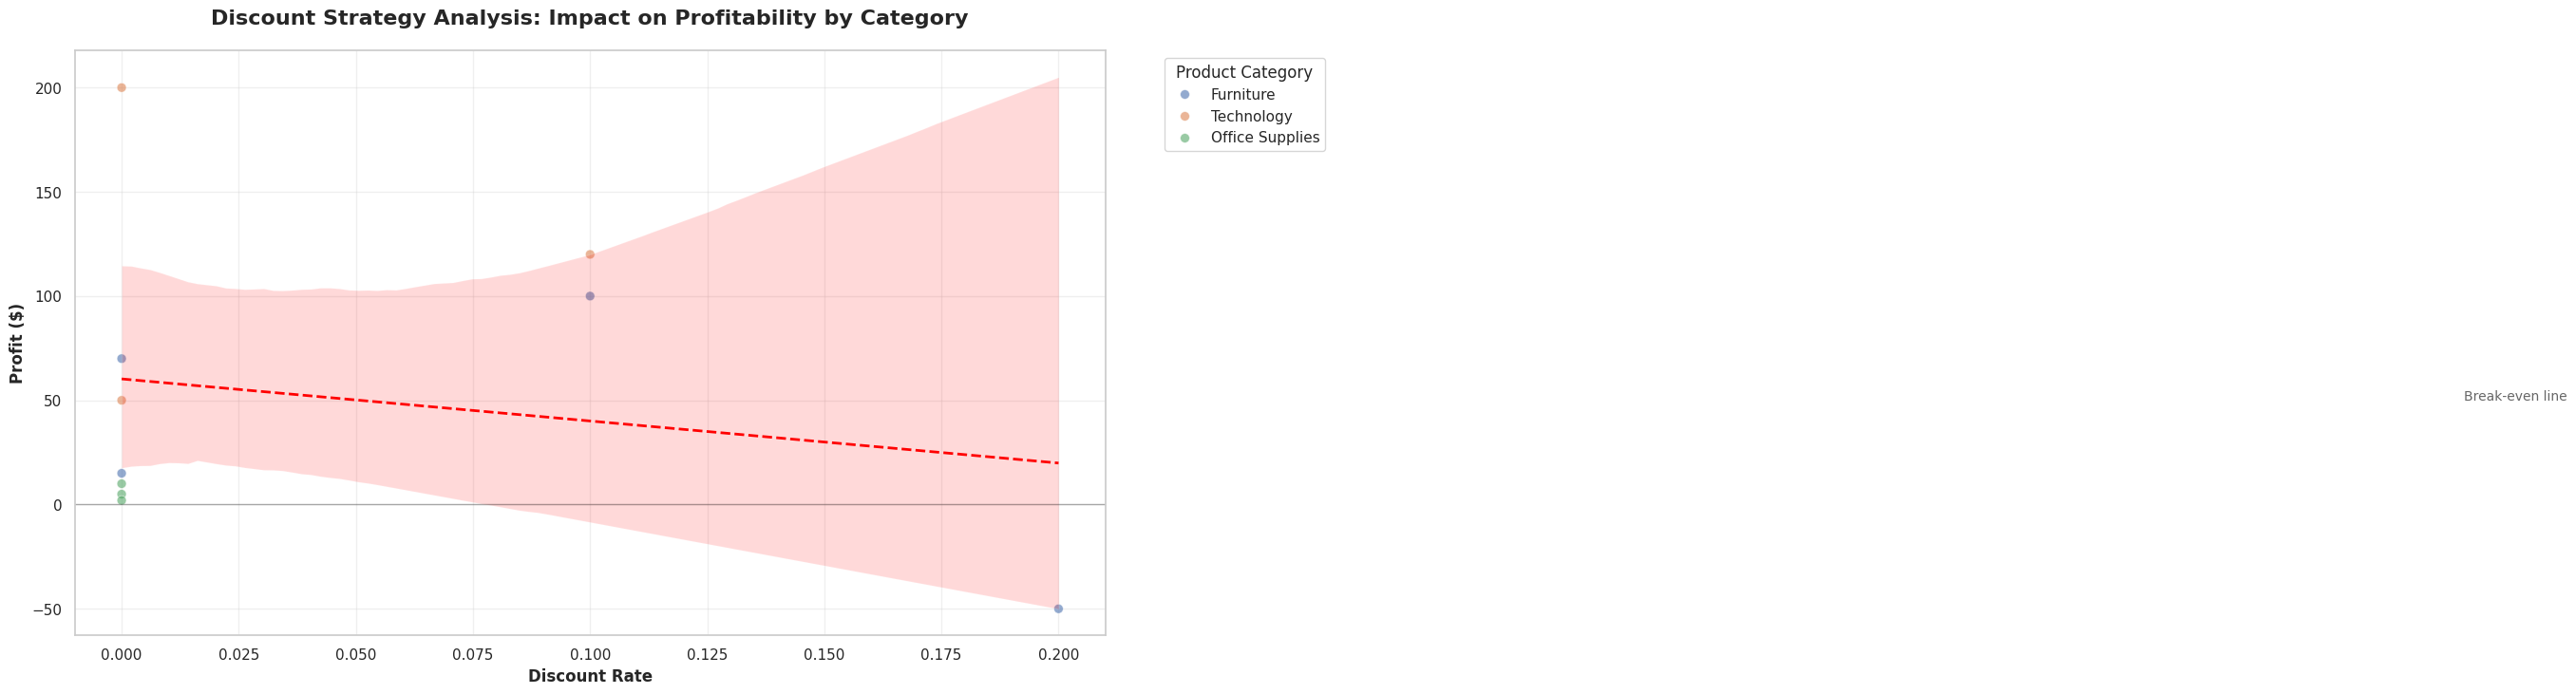

In [94]:
# Discount vs Profit Analysis
plt.figure(figsize=(14, 8))

# Create the scatter plot with category colors
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
               alpha=0.6, s=50)

# Add regression line for overall trend
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
           color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

# Customize the plot
plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')

# Add horizontal line at profit = 0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [95]:
# Analytical insights
print("Discount Analysis Insights:")
high_discount = df[df['Discount'] > 0.2]  # Discounts above 20%
print(f"• Transactions with >20% discount: {len(high_discount):,}")
print(f"• Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"• Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%")

# Category-specific analysis
print("\nCategory-specific discount impact:")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_loss = high_disc_cat['Profit'].mean()
        print(f"• {category}: Average profit at >20% discount = ${avg_loss:.2f}")

Discount Analysis Insights:
• Transactions with >20% discount: 0
• Average profit for high discounts: $nan
• Percentage of high-discount sales with losses: nan%

Category-specific discount impact:


4. Revue de la méthodologie et des outils

Créez une cellule de réduction avec une évaluation comparative de Matplotlib vs. Seaborn :

In [96]:
# Code to demonstrate library comparison
print("=== LIBRARY COMPARISON ANALYSIS ===")
print()

# Matplotlib strengths demonstrated
print("MATPLOTLIB STRENGTHS (from our analysis):")
print("• Fine-grained control over interactive widgets")
print("• Custom annotations and text positioning")
print("• Precise subplot layouts and figure sizing")
print("• Integration with ipywidgets for dynamic updates")
print()

# Seaborn strengths demonstrated
print("SEABORN STRENGTHS (from our analysis):")
print("• Built-in statistical visualizations (regplot)")
print("• Automatic color palettes and legends")
print("• Clean, publication-ready default styling")
print("• Easy categorical data visualization")
print()

print("SPEED COMPARISON:")
import time

# Time a simple matplotlib plot
start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

# Time a seaborn plot
start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Matplotlib basic plot: {matplotlib_time:.4f} seconds")
print(f"• Seaborn equivalent: {seaborn_time:.4f} seconds")

=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS (from our analysis):
• Fine-grained control over interactive widgets
• Custom annotations and text positioning
• Precise subplot layouts and figure sizing
• Integration with ipywidgets for dynamic updates

SEABORN STRENGTHS (from our analysis):
• Built-in statistical visualizations (regplot)
• Automatic color palettes and legends
• Clean, publication-ready default styling
• Easy categorical data visualization

SPEED COMPARISON:
• Matplotlib basic plot: 0.0203 seconds
• Seaborn equivalent: 0.0589 seconds


Modèle de recommandation :

« Pour une exploration rapide, j’utiliserai Matplotlib car il offre un rendu plus rapide pour les graphiques de base et une intégration fluide avec des widgets interactifs pour l’analyse dynamique.
Pour les présentations destinées aux parties prenantes, je préférerai Seaborn car il offre une esthétique prête à publier, des fonctionnalités statistiques intégrées et des palettes de couleurs professionnelles qui renforcent la communication des dirigeants. »

5. Livrable final

Votre Jupyter Notebook doit inclure :

✅ Structure professionnelle : en-têtes Markdown, commentaires clairs sur le code
📊 Visualisations : interactives et statiques, diagnostiques et explicatives
📝 Résumé exécutif : Top 3 à 5 points résumant les principales conclusions
Modèle de résumé exécutif amélioré :

In [97]:
# Generate automated insights for executive summary
print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===")
print()

# Sales performance metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"📊 BUSINESS PERFORMANCE:")
print(f"• Total Revenue: ${total_sales:,.0f}")
print(f"• Total Profit: ${total_profit:,.0f}")
print(f"• Overall Profit Margin: {profit_margin:.1f}%")
print()

# Geographic insights
top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
print(f"🗺️ GEOGRAPHIC PERFORMANCE:")
print(f"• Top performing state: {top_state} (${top_state_sales:,.0f})")
print(f"• Geographic concentration: Top 5 states = {(state_sales.tail(5).sum()/total_sales)*100:.1f}% of sales")
print()

# Product insights
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
print(f"🏆 PRODUCT PERFORMANCE:")
print(f"• Leading category: {top_category}")
print(f"• Most profitable product: {product_profit.index[0]}")
print()

# Discount insights
high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
print(f"💰 DISCOUNT STRATEGY INSIGHTS:")
print(f"• High discount risk: {high_discount_loss_rate:.1f}% of >20% discounts result in losses")
print(f"• Recommended max discount threshold: 20% to maintain profitability")

=== EXECUTIVE SUMMARY - KEY FINDINGS ===

📊 BUSINESS PERFORMANCE:
• Total Revenue: $5,050
• Total Profit: $522
• Overall Profit Margin: 10.3%

🗺️ GEOGRAPHIC PERFORMANCE:
• Top performing state: California ($2,500)
• Geographic concentration: Top 5 states = 100.0% of sales

🏆 PRODUCT PERFORMANCE:
• Leading category: Furniture
• Most profitable product: Machines

💰 DISCOUNT STRATEGY INSIGHTS:
• High discount risk: nan% of >20% discounts result in losses
• Recommended max discount threshold: 20% to maintain profitability


Exemple de découverte

« Les remises sur les meubles supérieures à 20 % entraînent des pertes moyennes de bénéfice de 15 %. »

Exemple de recommandation

« Limitez les réductions sur les meubles standards à un maximum de 20 %. Introduire des étapes d’approbation pour les exceptions. »

🧠 Défis avancés optionnels
📊 Construisez un tableau de bord interactif (par exemple, en utilisant ou ) pour combiner des graphiques.ipywidgetsVoilà

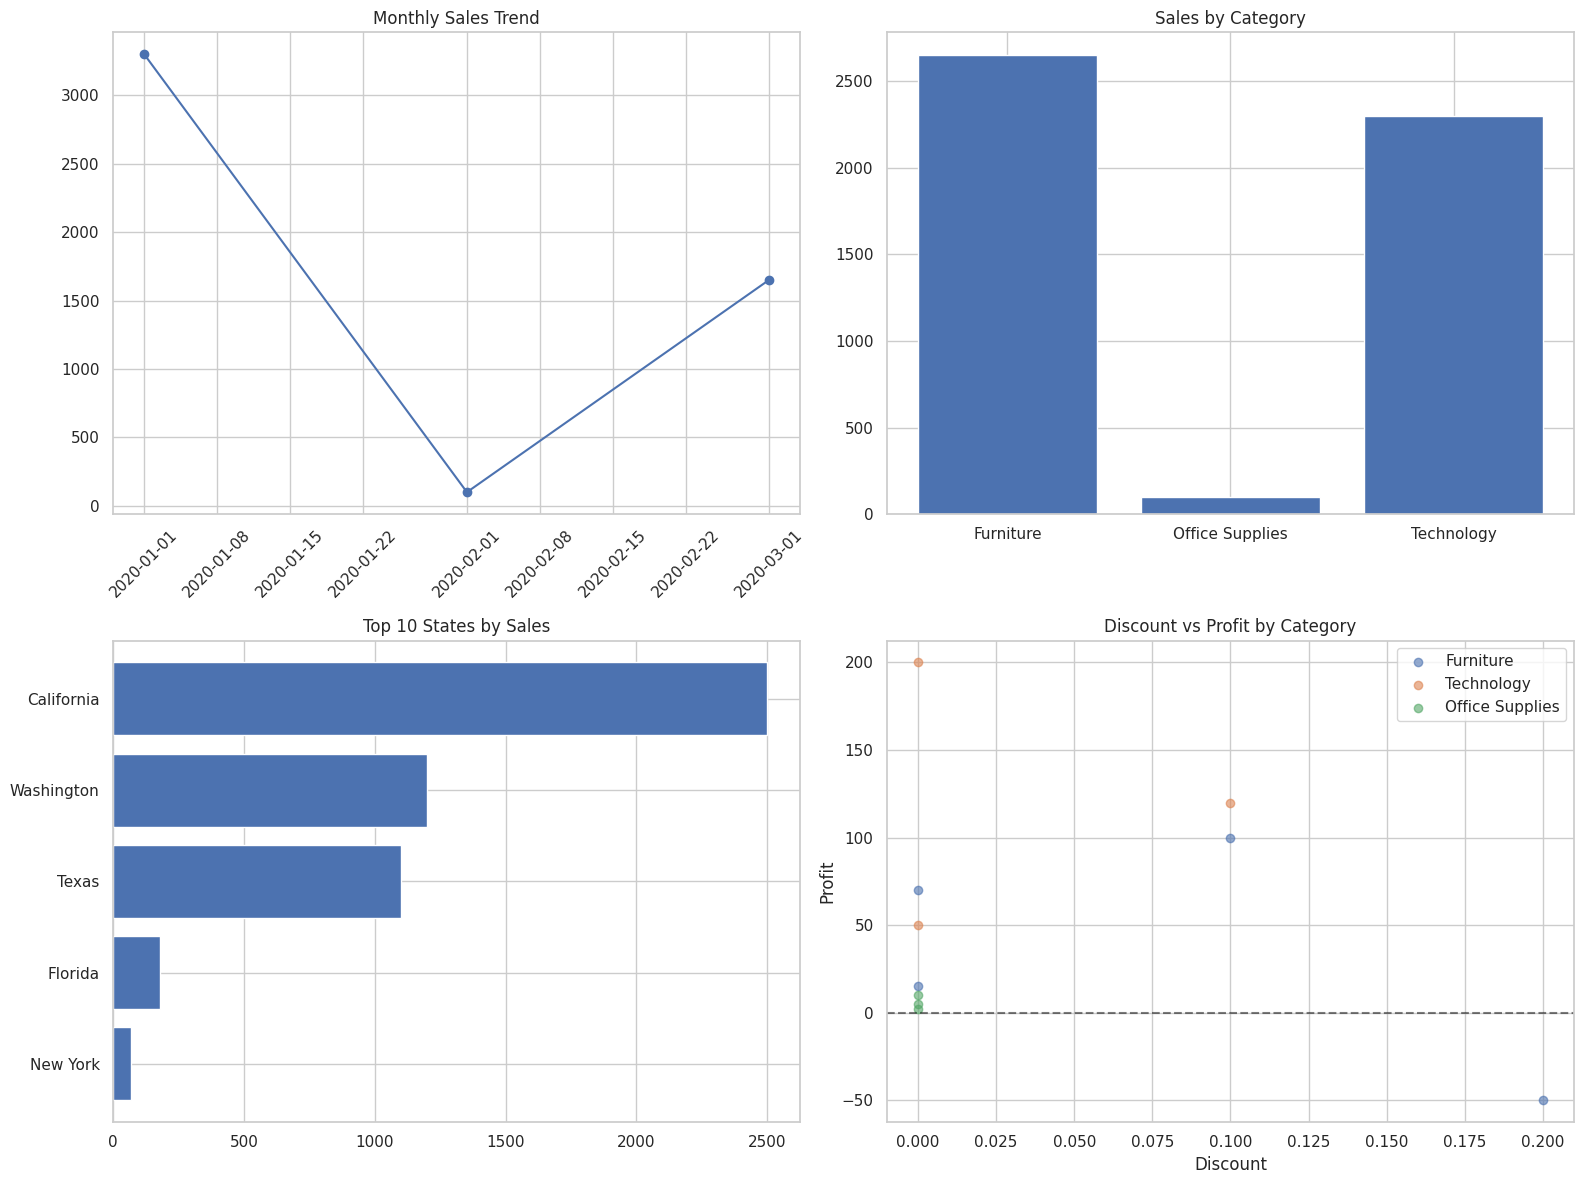

In [98]:
# Advanced: Multi-chart dashboard
def create_dashboard():
    # Create subplot layout
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Chart 1: Monthly sales trend
    monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
    ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o')
    ax1.set_title('Monthly Sales Trend')
    ax1.tick_params(axis='x', rotation=45)

    # Chart 2: Category performance
    category_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(category_sales.index, category_sales.values)
    ax2.set_title('Sales by Category')

    # Chart 3: State performance (top 10)
    top_10_states = state_sales.tail(10)
    ax3.barh(range(len(top_10_states)), top_10_states.values)
    ax3.set_yticks(range(len(top_10_states)))
    ax3.set_yticklabels(top_10_states.index)
    ax3.set_title('Top 10 States by Sales')

    # Chart 4: Discount vs Profit
    for category in df['Category'].unique():
        cat_data = df[df['Category'] == category]
        ax4.scatter(cat_data['Discount'], cat_data['Profit'],
                   label=category, alpha=0.6)
    ax4.set_xlabel('Discount')
    ax4.set_ylabel('Profit')
    ax4.set_title('Discount vs Profit by Category')
    ax4.legend()
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Call the dashboard function
create_dashboard()

🏷️ Annoter les valeurs aberrantes dans le rapport à la remise vs profit (par exemple, indiquer les 3 transactions les plus rentables et les moins rentables).

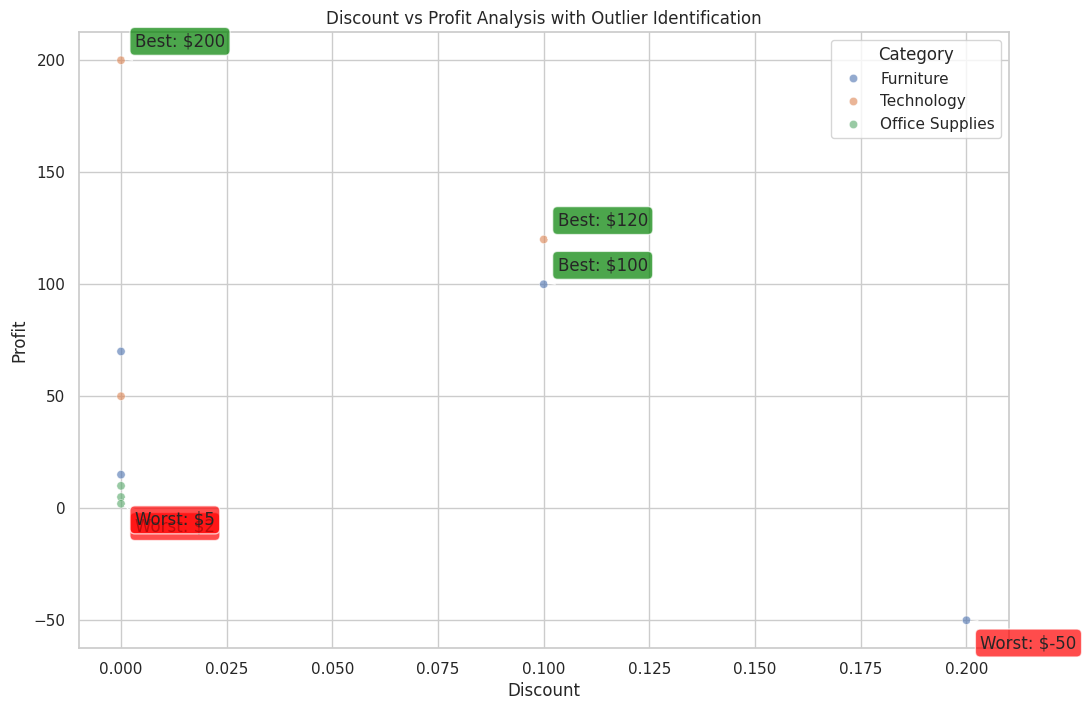

In [99]:
# Advanced: Outlier analysis with annotations
plt.figure(figsize=(12, 8))

# Create base scatter plot
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)

# Identify and annotate outliers
top_3_profitable = df.nlargest(3, 'Profit')
bottom_3_profitable = df.nsmallest(3, 'Profit')

# Annotate top performers
for idx, row in top_3_profitable.iterrows():
    plt.annotate(f'Best: ${row["Profit"]:.0f}',
                xy=(row['Discount'], row['Profit']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

# Annotate worst performers
for idx, row in bottom_3_profitable.iterrows():
    plt.annotate(f'Worst: ${row["Profit"]:.0f}',
                xy=(row['Discount'], row['Profit']),
                xytext=(10, -20), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.title('Discount vs Profit Analysis with Outlier Identification')
plt.show()

⚙️ Reconstruisez un tableau interactif avec Plotly Express. Comparez brièvement les avantages/inconvénients par rapport à Matplotlib + ipywidgets.

In [100]:
# Advanced: Plotly comparison
import plotly.express as px
import plotly.graph_objects as go

# Create interactive Plotly version of discount analysis
fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                hover_data=['Product Name', 'Sales'],
                title='Interactive Discount vs Profit Analysis (Plotly)')

# Add trendline
fig.add_traces(px.scatter(df, x='Discount', y='Profit', trendline='ols').data[1])

fig.show()

print("PLOTLY vs MATPLOTLIB COMPARISON:")
print("Plotly Advantages:")
print("• Built-in interactivity (zoom, pan, hover)")
print("• Easy to share online")
print("• Professional tooltips and legends")
print("• Automatic responsive design")
print()
print("Matplotlib + ipywidgets Advantages:")
print("• More customization control")
print("• Better integration with Jupyter workflows")
print("• Smaller file sizes")
print("• Familiar to Python data scientists")

PLOTLY vs MATPLOTLIB COMPARISON:
Plotly Advantages:
• Built-in interactivity (zoom, pan, hover)
• Easy to share online
• Professional tooltips and legends
• Automatic responsive design

Matplotlib + ipywidgets Advantages:
• More customization control
• Better integration with Jupyter workflows
• Smaller file sizes
• Familiar to Python data scientists
